In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from dl_model.trainer_lstm import train_lstm
from outils.gridsearch import grid_search

Train: (142881, 120)
Validation: (30617, 120)
Test : (30618, 120)
GridSearch lancé sur 4 combinaisons
Parallelisation avec n_jobs=-1

 Meilleurs paramètres (val_loss) :
model_type         gru
batch_size          64
epochs              20
verbose              0
horizon              1
val_loss      0.796247
val_mae       0.631909
Name: 2, dtype: object
Score: 0.7962467074394226


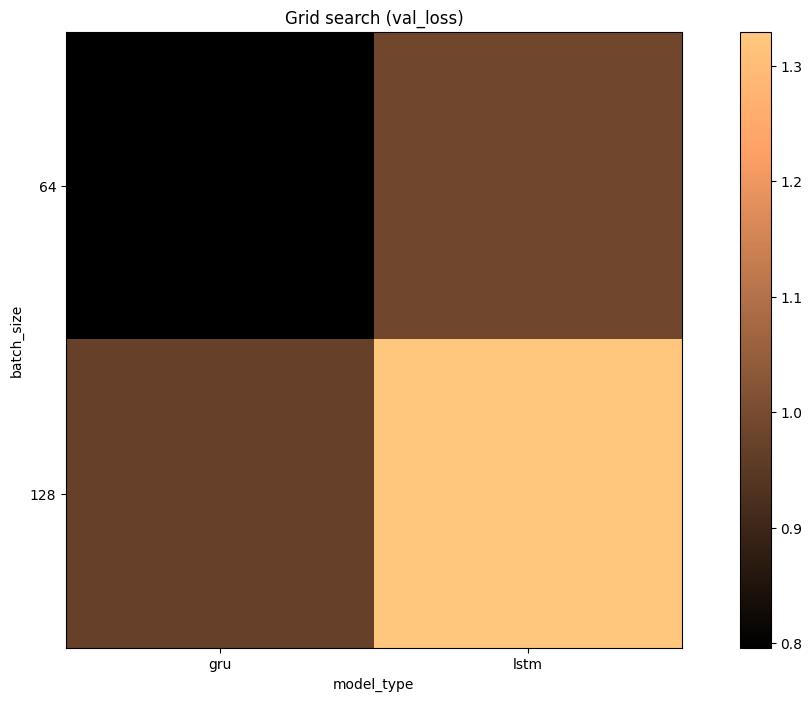

  model_type  batch_size  epochs  verbose  horizon  val_loss   val_mae
0       lstm          64      20        0        1  0.986958  0.694417
1       lstm         128      20        0        1  1.329485  0.795899
2        gru          64      20        0        1  0.796247  0.631909
3        gru         128      20        0        1  0.970318  0.749872


In [10]:
# Chargement du jeu de données
df = pd.read_csv("WADI_clean.csv")

target = "3_LT_001_PV" # pour l'instant on ne le fait que sur une cible


# features = tout sauf la target
X = df.drop(columns=[target])

# Valeurs manquantes complétées
X = X.ffill()

y = df[target]

# Suppression des colonnes non numériques
X = X.select_dtypes(include=[np.number])

# Split
# /!\ : pas de shuffle pour séries temporelles

split_1 = int(len(df) * 0.7)
split_2 = int(len(df) * 0.85)

X_train = X.iloc[:split_1]
y_train = y.iloc[:split_1]

X_val = X.iloc[split_1:split_2]
y_val = y.iloc[split_1:split_2]

X_test  = X.iloc[split_2:]
y_test  = y.iloc[split_2:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test :", X_test.shape)

# Gridsearch
p_grid = {
    "model_type": ["lstm", "gru"],
    "batch_size": [64, 128],# premier test
    "epochs": [20],
    "verbose": [0], # pour empêcher de tout voir
    "horizon": [1]  # ou 12 si multi-step
}

df_results = grid_search(
    trainer=train_lstm,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    p_grid=p_grid,
    score_opt="val_loss"
)

print(df_results)

GridSearch lancé sur 4 combinaisons
Parallelisation avec n_jobs=-1

 Meilleurs paramètres (val_loss) :
model_type    bidirectional_lstm
batch_size                    32
epochs                        20
verbose                        0
horizon                        1
val_loss                0.665583
val_mae                 0.618008
Name: 2, dtype: object
Score: 0.6655832529067993


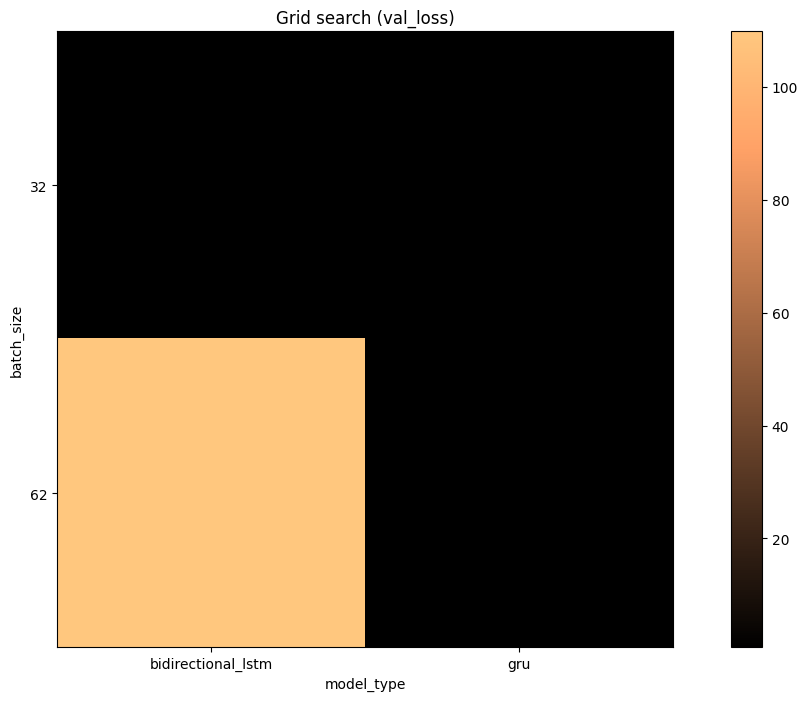

           model_type  batch_size  epochs  verbose  horizon    val_loss  \
0                 gru          32      20        0        1    0.821931   
1                 gru          62      20        0        1    0.889448   
2  bidirectional_lstm          32      20        0        1    0.665583   
3  bidirectional_lstm          62      20        0        1  109.850769   

    val_mae  
0  0.692032  
1  0.649928  
2  0.618008  
3  3.033309  


In [11]:
# Gridsearch
p_grid = {
    "model_type": ["gru", "bidirectional_lstm"],
    "batch_size": [32, 62],# deuxième test
    "epochs": [20],
    "verbose": [0], # pour empêcher de tout voir
    "horizon": [1]  # ou 12 si multi-step
}

df_results = grid_search(
    trainer=train_lstm, # à changer en multistep la fois d'après
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    p_grid=p_grid,
    score_opt="val_loss"
)

print(df_results)

GridSearch lancé sur 2 combinaisons
Parallelisation avec n_jobs=-1

 Meilleurs paramètres (val_loss) :
model_type    bidirectional_lstm
batch_size                    32
epochs                        20
verbose                        0
horizon                        1
val_loss                0.739132
val_mae                 0.634044
Name: 1, dtype: object
Score: 0.7391321063041687


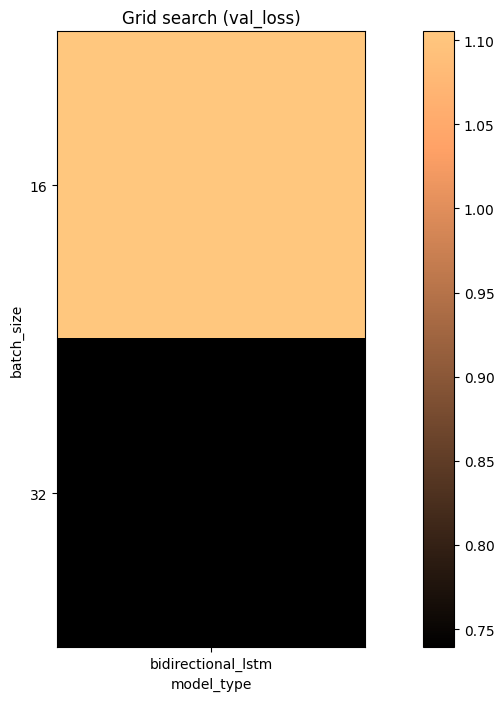

           model_type  batch_size  epochs  verbose  horizon  val_loss  \
0  bidirectional_lstm          16      20        0        1  1.105228   
1  bidirectional_lstm          32      20        0        1  0.739132   

    val_mae  
0  0.843377  
1  0.634044  


In [12]:
# Gridsearch
p_grid = {
    "model_type": ["bidirectional_lstm"],
    "batch_size": [16, 32], # troisième test
    "epochs": [20],
    "verbose": [0], # pour empêcher de tout voir
    "horizon": [1]  # ou 12 si multi-step
}

df_results = grid_search(
    trainer=train_lstm, # à changer en multistep la fois d'après
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    p_grid=p_grid,
    score_opt="val_loss"
)

print(df_results)

In [13]:
best = df_results.loc[df_results["val_loss"].idxmin()]

In [14]:
model, scaler, history = train_lstm(
    X_train, y_train,
    X_val, y_val,
    model_type=best["model_type"],
    batch_size=int(best["batch_size"]),
    epochs=int(best["epochs"])
)

C:\Users\ELEVEN\miniconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
   4462/Unknown 511s 113ms/step - loss: 788.7371 - mae: 20.9917

C:\Users\ELEVEN\miniconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4462/4462 ━━━━━━━━━━━━━━━━━━━━ 546s 121ms/step - loss: 250.7110 - mae: 9.4146 - val_loss: 97.8461 - val_mae: 3.2077 - learning_rate: 0.0010
Epoch 2/20
4462/4462 ━━━━━━━━━━━━━━━━━━━━ 699s 151ms/step - loss: 17.1406 - mae: 3.3024 - val_loss: 87.4710 - val_mae: 3.1018 - learning_rate: 0.0010
Epoch 3/20
4462/4462 ━━━━━━━━━━━━━━━━━━━━ 532s 119ms/step - loss: 16.4692 - mae: 3.2309 - val_loss: 74.9045 - val_mae: 2.9604 - learning_rate: 0.0010
Epoch 4/20
4462/4462 ━━━━━━━━━━━━━━━━━━━━ 535s 120ms/step - loss: 16.2379 - mae: 3.2176 - val_loss: 7.4477 - val_mae: 1.4782 - learning_rate: 0.0010
Epoch 5/20
4462/4462 ━━━━━━━━━━━━━━━━━━━━ 549s 123ms/step - loss: 15.3876 - mae: 3.1234 - val_loss: 1.5422 - val_mae: 1.0100 - learning_rate: 0.0010
Epoch 6/20
4462/4462 ━━━━━━━━━━━━━━━━━━━━ 559s 125ms/step - loss: 15.1044 - mae: 3.0955 - val_loss: 1.2445 - val_mae: 0.8681 - learning_rate: 0.0010
Epoch 7/20
4462/4462 ━━━━━━━━━━━━━━━━━━━━ 543s 122ms/step - loss: 14.6565 - mae: 3.0543 - val_loss: 1.1553 - val_

In [11]:
# Prédiction

In [37]:
from dl_model.forecast_lstm import forecast_lstm_direct
from dl_model.config_lstm import WINDOW_SIZE

In [41]:
preds = forecast_lstm_direct(model=model,
    X=X,        # ou une partie récente du dataset
    scaler=scaler,
    saisonalite=WINDOW_SIZE)

In [42]:
preds

array([64.4322], dtype=float32)

In [43]:
from dl_model.forecast_lstm import forecast_lstm

In [45]:
preds = forecast_lstm(model=model,
    val=X,        # ou une partie récente du dataset
    scaler=scaler,
    saisonalite=WINDOW_SIZE,
    n_steps = 20)

In [46]:
preds

array([[64.4322  ],
       [64.51742 ],
       [64.526436],
       [64.45761 ],
       [64.49141 ],
       [64.4981  ],
       [64.47799 ],
       [64.45697 ],
       [64.45433 ],
       [64.44636 ],
       [64.51586 ],
       [64.519356],
       [64.525734],
       [64.47854 ],
       [64.46536 ],
       [64.44983 ],
       [64.46871 ],
       [64.51069 ],
       [64.53056 ],
       [64.47849 ]], dtype=float32)